# QAPINN 



## 1. Dependencies 

In [1]:
import importlib, subprocess, sys
def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg); print(f"[ok] {pkg}")
    except ImportError:
        print(f"[..] installing {pipname or pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname or pkg])
for p in ["torch", "pennylane", "scipy", "numpy", "matplotlib"]:
    ensure(p)
print("[done]")

[ok] torch
[ok] pennylane
[ok] scipy
[ok] numpy
[ok] matplotlib
[done]


## 2. Imports & configuration

In [2]:
import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from scipy.stats import qmc
import matplotlib.pyplot as plt

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED)

DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_ROOT = "qapinn_runs"
for sub in ["checkpoints", "results", "figures", "models"]:
    os.makedirs(os.path.join(CKPT_ROOT, sub), exist_ok=True)

N_U = 120          # IC+BC points
print(f"[cfg] torch {torch.__version__} | pennylane {qml.__version__} | {device} | {DTYPE}")

[cfg] torch 2.13.0+cu130 | pennylane 0.45.1 | cpu | torch.float32


## 3. The two PDEs + training-data maker
Both live on $x\in[-1,1],\ t\in[0,1]$ with zero boundary conditions, so all code is shared:

- **Burgers**: $u_t + u\,u_x - \nu\,u_{xx} = 0$, $u(0,x)=-\sin(\pi x)$. Tier 1 uses $\nu=0.05$
  (moderate front, resolvable); Tier 2 uses the hard $\nu=0.01/\pi$ (sharp shock).
- **Heat**: $u_t - \alpha\,u_{xx} = 0$, $u(0,x)=\sin(\pi x)$, exact solution
  $\sin(\pi x)e^{-\alpha\pi^2 t}$ with $\alpha=0.1$ (nice dynamic range over $t\in[0,1]$).



In [3]:
NU_EASY  = 0.05          # Tier-1 Burgers viscosity
NU_HARD  = 0.01/np.pi    # Tier-2 Burgers viscosity (Raissi/Shah benchmark)
ALPHA    = 0.10          # Heat diffusivity

def initial_condition(pde, x):
    return -np.sin(np.pi*x) if pde == "burgers" else np.sin(np.pi*x)

def make_training_data(pde, n_f, tmax=1.0, shock_frac=0.0, seed=SEED):
    """Returns torch tensors (x_u,t_u,u_u, x_f,t_f) on the right device/dtype."""
    rng = np.random.default_rng(seed)
    # initial-condition points
    n_ic = N_U // 2
    x_ic = rng.uniform(-1, 1, n_ic); t_ic = np.zeros(n_ic)
    u_ic = initial_condition(pde, x_ic)
    # boundary points
    n_bc = N_U - n_ic
    t_bc = rng.uniform(0, tmax, n_bc)
    x_bc = np.where(rng.random(n_bc) < 0.5, -1.0, 1.0)
    u_bc = np.zeros(n_bc)
    x_u = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
    t_u = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
    u_u = np.concatenate([u_ic, u_bc]).reshape(-1, 1)
    # collocation: LHS base + optional shock-focused extra (Burgers only)
    n_sh = int(shock_frac * n_f) if pde == "burgers" else 0
    n_lhs = n_f - n_sh
    lhs = qmc.LatinHypercube(d=2, seed=seed)
    s = lhs.random(n_lhs)
    x_f1 = -1.0 + 2.0*s[:, 0]; t_f1 = tmax*s[:, 1]
    x_f2 = np.clip(rng.normal(0.0, 0.15, n_sh), -1, 1)
    t_f2 = rng.uniform(0.25*tmax, tmax, n_sh)
    x_f = np.concatenate([x_f1, x_f2]).reshape(-1, 1)
    t_f = np.concatenate([t_f1, t_f2]).reshape(-1, 1)
    T = lambda a: torch.tensor(a, dtype=DTYPE, device=device)
    return T(x_u), T(t_u), T(u_u), T(x_f), T(t_f)

print("[ok] data maker ready")

[ok] data maker ready


## 4. Reference solutions (exact, cached)
- Heat: closed form.
- Burgers (any ν): the Phase-1 Cole–Hopf quadrature.

Each reference grid (256×256) is computed once and cached to disk; `relative_l2` measures
$\|\hat u - u\| / \|u\|$ against it.

In [4]:
def burgers_analytical(x_arr, t_arr, nu, n_quad=4000):
    x_arr = np.atleast_1d(np.asarray(x_arr, float)); t_arr = np.atleast_1d(np.asarray(t_arr, float))
    u = np.zeros((len(t_arr), len(x_arr)))
    y = np.linspace(-3.0, 3.0, n_quad)
    cos_term = np.cos(np.pi*y) / (2.0*np.pi*nu)
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi*x_arr); continue
        F = cos_term.reshape(1, -1) + (x_arr.reshape(-1, 1) - y.reshape(1, -1))**2/(4.0*nu*ti)
        ml = np.max(-F, axis=1, keepdims=True); w = np.exp(-F - ml)
        num = np.sum((x_arr.reshape(-1, 1) - y.reshape(1, -1))/ti * w, axis=1)
        den = np.sum(w, axis=1)
        u[i, :] = np.where(den > 0, num/den, 0.0)
    return u

_REFS = {}
def reference(pde, nu):
    key = (pde, round(float(nu), 8))
    if key in _REFS: return _REFS[key]
    path = os.path.join(CKPT_ROOT, "results", f"ref_{pde}_{nu:.6f}.npz")
    if os.path.exists(path):
        d = np.load(path); out = (d["x"], d["t"], d["U"])
    else:
        x = np.linspace(-1, 1, 256); t = np.linspace(0, 1, 256)
        if pde == "heat":
            U = np.sin(np.pi*x)[None, :] * np.exp(-nu*np.pi**2*t)[:, None]
        else:
            print(f"[ref] computing Cole-Hopf for nu={nu:.5f} (once, ~20s)...")
            U = burgers_analytical(x, t, nu)
        np.savez(path, x=x, t=t, U=U); out = (x, t, U)
    _REFS[key] = out
    return out

@torch.no_grad()
def relative_l2(model, pde, nu):
    x, t, U = reference(pde, nu)
    XX, TT = np.meshgrid(x, t)
    xf = torch.tensor(XX.reshape(-1, 1), dtype=DTYPE, device=device)
    tf = torch.tensor(TT.reshape(-1, 1), dtype=DTYPE, device=device)
    up = model(xf, tf).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up - U)/np.linalg.norm(U)), up

def frozen_ic_baseline(pde, nu):
    """L2 of predicting the initial condition for all t -- the honest 'no-dynamics' bar."""
    x, t, U = reference(pde, nu)
    IC = np.tile(initial_condition(pde, x), (len(t), 1))
    return float(np.linalg.norm(IC - U)/np.linalg.norm(U))

print("[ok] references ready")

[ok] references ready


## 5. The QAPINN model


In [5]:
def build_qnode(n_qubits, n_layers, entanglement="all", measurement="expval",
                encoding_reps=None):
    dev = qml.device("default.qubit", wires=n_qubits)
    reps = n_layers if encoding_reps is None else encoding_reps
    def entangle():
        if entanglement == "none": return
        if entanglement == "linear":
            for q in range(n_qubits - 1): qml.CNOT(wires=[q, q + 1])
        elif entanglement == "all":
            for a in range(n_qubits):
                for b in range(a + 1, n_qubits): qml.CNOT(wires=[a, b])
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for l in range(n_layers):
            if l < reps:                                  # data re-uploading
                for q in range(n_qubits):
                    qml.RY(inputs[:, q % 2], wires=q)
            for q in range(n_qubits):
                qml.RX(weights[l, q], wires=q)
            entangle()
        if measurement == "expval":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        return qml.probs(wires=range(n_qubits))
    out_dim = n_qubits if measurement == "expval" else 2**n_qubits
    return circuit, {"weights": (n_layers, n_qubits)}, out_dim


class QAPINN(nn.Module):
    """VQC first layer (re-uploading, trainable input scale) + deep classical body."""
    def __init__(self, n_qubits=3, n_layers=6, entanglement="all", measurement="expval",
                 encoding_reps=None, head_width=20, head_depth=5):
        super().__init__()
        self.cfg = dict(n_qubits=n_qubits, n_layers=n_layers, entanglement=entanglement,
                        measurement=measurement,
                        encoding_reps=(n_layers if encoding_reps is None else encoding_reps),
                        head_width=head_width, head_depth=head_depth)
        qnode, wshapes, out_dim = build_qnode(n_qubits, n_layers, entanglement,
                                              measurement, encoding_reps)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.in_scale = nn.Parameter(torch.ones(2))
        layers = [nn.Linear(out_dim, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in self.head:                                # Xavier init (as Phase 1)
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.qlayer(inp)
        return self.head(feat)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

_m = QAPINN(3)
print(f"[ok] model ready — 3-qubit example: {count_params(_m)} params "
      f"(vs 101 in the failed v3, 3021 in Phase 1)")
del _m

[ok] model ready — 3-qubit example: 1801 params (vs 101 in the failed v3, 3021 in Phase 1)


## 6. Physics-informed loss (PDE-aware, exact autograd derivatives)

In [6]:
W_IC = 10.0

def pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde, nu, w_ic=None):
    w = W_IC if w_ic is None else w_ic
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u)**2)
    xf = x_f.clone().requires_grad_(True)
    tf = t_f.clone().requires_grad_(True)
    u = model(xf, tf)
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    if pde == "burgers":
        f = u_t + u*u_x - nu*u_xx
    else:                              # heat
        f = u_t - nu*u_xx
    mse_f = torch.mean(f**2)
    return w*mse_u + mse_f, mse_u, mse_f
print("[ok] loss ready")

[ok] loss ready


## 7. Schedule-based training engine 

In [7]:
def ckpt_path(tag):
    return os.path.join(CKPT_ROOT, "checkpoints", f"{tag}.pt")

def _state_copy(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_schedule(tag, model, pde, nu, schedule, n_f=2000,
                   ckpt_every=250, log_every=100):
    model.to(device)
    hist = {"iters": [], "loss": [], "mse_u": [], "mse_f": [], "phase": []}
    start_phase, start_it, opt_state = 0, 0, None
    best_loss, best_state = float("inf"), None
    p = ckpt_path(tag)
    if os.path.exists(p):
        ck = torch.load(p, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"]); hist = ck["history"]
        start_phase, start_it = ck["phase"], ck["it"]
        opt_state = ck.get("opt_state")
        best_loss = ck.get("best_loss", best_loss); best_state = ck.get("best_state")
        print(f"[resume] '{tag}' at phase {start_phase}, it {start_it}")
    if start_phase >= len(schedule):
        print(f"[done] '{tag}' already finished. Delete its checkpoint to redo.")
        return hist

    cur = {"phase": start_phase, "it": start_it, "opt": None}
    def save():
        tmp = p + ".tmp"
        torch.save({"phase": cur["phase"], "it": cur["it"],
                    "model_state": model.state_dict(),
                    "opt_state": (cur["opt"].state_dict() if cur["opt"] is not None else None),
                    "history": hist, "best_loss": best_loss, "best_state": best_state}, tmp)
        os.replace(tmp, p)

    gstep = len(hist["loss"])
    t0 = time.time()
    try:
        for pi in range(start_phase, len(schedule)):
            ph = schedule[pi]
            cur["phase"] = pi
            x_u, t_u, u_u, x_f, t_f = make_training_data(
                pde, n_f, tmax=ph.get("tmax", 1.0),
                shock_frac=ph.get("shock_frac", 0.0), seed=SEED + 13*pi)
            it0 = start_it if pi == start_phase else 0

            if ph["kind"] == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=ph.get("lr", 8e-3))
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                for it in range(it0, ph["iters"]):
                    cur["it"] = it
                    opt.zero_grad()
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    loss.backward(); opt.step()
                    li = loss.item(); gstep += 1
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    if math.isfinite(li) and li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    if (it + 1) % log_every == 0:
                        print(f"  [{tag}] P{pi} adam it {it+1:5d}/{ph['iters']} "
                              f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                              f"[{(time.time()-t0)/60:.1f} min]")
                    if (it + 1) % ckpt_every == 0:
                        cur["it"] = it + 1; save()

            else:  # ---- L-BFGS phase, chunked ----
                chunk = ph.get("chunk", 150)
                opt = torch.optim.LBFGS(model.parameters(), max_iter=chunk,
                                        history_size=60, line_search_fn="strong_wolfe",
                                        tolerance_grad=1e-12, tolerance_change=1e-14)
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                n_chunks = math.ceil(ph["iters"]/chunk)
                for c in range(it0 // chunk, n_chunks):
                    def closure():
                        opt.zero_grad()
                        L, _, _ = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                        L.backward(); return L
                    opt.step(closure)
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    li = loss.item(); gstep += chunk
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    print(f"  [{tag}] P{pi} lbfgs chunk {c+1}/{n_chunks} "
                          f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                          f"[{(time.time()-t0)/60:.1f} min]")
                    if (not math.isfinite(li)) or li > 50*max(best_loss, 1e-12):
                        print(f"  [{tag}] L-BFGS blow-up guard triggered -> "
                              f"restoring best state (loss {best_loss:.3e}) and stopping phase.")
                        if best_state is not None:
                            model.load_state_dict(best_state)
                        break
                    if li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    cur["it"] = (c + 1)*chunk; save()

            start_it = 0
            cur["phase"], cur["it"], cur["opt"] = pi + 1, 0, None
            save()

        # keep the best weights seen anywhere in training
        if best_state is not None and hist["loss"] and best_loss < hist["loss"][-1]*0.999:
            model.load_state_dict(best_state)
            print(f"[{tag}] restored overall best state (loss {best_loss:.3e})")
        save()
    except KeyboardInterrupt:
        save()
        print(f"\n[interrupted] '{tag}' checkpointed at phase {cur['phase']}, "
              f"it {cur['it']}. Re-run this cell to continue.")
        raise
    print(f"[finished] '{tag}' total wall time {(time.time()-t0)/60:.1f} min")
    return hist
print("[ok] engine ready")

[ok] engine ready


## 8. Results recorder (CSV + saved models + loss histories)

In [8]:
import csv
MASTER_CSV = os.path.join(CKPT_ROOT, "results", "master_results.csv")
FIELDS = ["tag","pde","nu","n_qubits","n_layers","entanglement","measurement",
          "encoding_reps","head_width","head_depth","optimizer","n_iters","params",
          "L2","mse_u","mse_f","final_loss"]

def record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs"):
    l2, _ = relative_l2(model, pde, nu)
    row = {"tag": tag, "pde": pde, "nu": f"{nu:.6f}", **model.cfg,
           "optimizer": optimizer,
           "n_iters": hist["iters"][-1] if hist["iters"] else 0,
           "params": count_params(model), "L2": f"{l2:.6e}",
           "mse_u": f"{hist['mse_u'][-1]:.6e}" if hist["mse_u"] else "",
           "mse_f": f"{hist['mse_f'][-1]:.6e}" if hist["mse_f"] else "",
           "final_loss": f"{hist['loss'][-1]:.6e}" if hist["loss"] else ""}
    row = {k: v for k, v in row.items() if k in FIELDS}
    exists = os.path.exists(MASTER_CSV)
    with open(MASTER_CSV, "a", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS)
        if not exists: w.writeheader()
        w.writerow(row)
    torch.save(model.state_dict(), os.path.join(CKPT_ROOT, "models", f"{tag}.pt"))
    np.savez(os.path.join(CKPT_ROOT, "results", f"{tag}_history.npz"),
             iters=np.array(hist["iters"]), loss=np.array(hist["loss"]),
             mse_u=np.array(hist["mse_u"]), mse_f=np.array(hist["mse_f"]),
             phase=np.array(hist["phase"]))
    print(f"[record] {tag}: L2={l2:.3e}, params={count_params(model)}")
    return l2
print("[ok] recorder ready")

[ok] recorder ready


---
# TIER 1 : the runs that converge (Burgers ν=0.05 + Heat, qubits 3/4/5)

Six runs. Each: **Adam 1000** (lr 8e-3) → **L-BFGS 400** (chunks of 100). All checkpointed.


In [9]:
T1_results = {}
TIER1_SCHEDULE = [
    {"kind": "adam",  "lr": 8e-3, "iters": 1000, "tmax": 1.0, "shock_frac": 0.15},
    {"kind": "lbfgs", "iters": 400, "chunk": 100, "tmax": 1.0, "shock_frac": 0.15},
]
for pde, nu in [("burgers", NU_EASY), ("heat", ALPHA)]:
    for nq in [3, 4, 5]:
        tag = f"T1_{pde}_q{nq}"
        print(f"\n=== {tag} ({nq} qubits, depth 6, re-upload, deep body) ===")
        model = QAPINN(n_qubits=nq, n_layers=6, entanglement="all",
                       measurement="expval", head_width=20, head_depth=5)
        print(f"    parameters: {count_params(model)}")
        sched = [dict(s) for s in TIER1_SCHEDULE]
        if pde == "heat":
            for s in sched: s["shock_frac"] = 0.0     # no shock in heat
        hist = train_schedule(tag, model, pde, nu, sched, n_f=2000,
                              ckpt_every=250, log_every=200)
        l2 = record_result(tag, model, hist, pde, nu)
        T1_results[(pde, nq)] = (model, hist, l2)
        print(f"    --> L2 = {l2:.4e}")
print("\n[TIER 1 complete]")


=== T1_burgers_q3 (3 qubits, depth 6, re-upload, deep body) ===
    parameters: 1801
  [T1_burgers_q3] P0 adam it   200/1000 loss=3.037e-01 (u=1.36e-02, f=1.68e-01) [2.1 min]
  [T1_burgers_q3] P0 adam it   400/1000 loss=1.800e-01 (u=7.38e-03, f=1.06e-01) [4.0 min]
  [T1_burgers_q3] P0 adam it   600/1000 loss=8.860e-02 (u=3.33e-03, f=5.53e-02) [6.3 min]
  [T1_burgers_q3] P0 adam it   800/1000 loss=6.020e-02 (u=2.11e-03, f=3.91e-02) [9.3 min]
  [T1_burgers_q3] P0 adam it  1000/1000 loss=6.118e-02 (u=3.16e-03, f=2.96e-02) [11.4 min]
  [T1_burgers_q3] P1 lbfgs chunk 1/4 loss=2.875e-02 (u=5.17e-04, f=2.36e-02) [12.9 min]
  [T1_burgers_q3] P1 lbfgs chunk 2/4 loss=9.109e-03 (u=1.62e-04, f=7.49e-03) [14.0 min]
  [T1_burgers_q3] P1 lbfgs chunk 3/4 loss=4.455e-03 (u=6.25e-05, f=3.83e-03) [15.1 min]
  [T1_burgers_q3] P1 lbfgs chunk 4/4 loss=2.295e-03 (u=2.86e-05, f=2.01e-03) [16.0 min]
[finished] 'T1_burgers_q3' total wall time 16.0 min
[ref] computing Cole-Hopf for nu=0.05000 (once, ~20s)...
[r

## Tier 1 : verdict cell 
Compares every run against its PDE's **frozen-IC baseline** (predicting the initial condition
for all $t$ , the no-dynamics bar) and against targets. Prints PASS / PARTIAL / FAIL.

In [10]:
print(f"{'run':22s} {'params':>7} {'L2':>11} {'frozen-IC bar':>13}  verdict")
targets = {"burgers": 0.15, "heat": 0.05}
all_ok, any_fail = True, False
for pde, nu in [("burgers", NU_EASY), ("heat", ALPHA)]:
    bar = frozen_ic_baseline(pde, nu)
    for nq in [3, 4, 5]:
        m, h, l2 = T1_results[(pde, nq)]
        if l2 < targets[pde]:  v = "GOOD"
        elif l2 < 0.5*bar:     v = "ok (beats bar 2x)"; all_ok = False
        elif l2 < bar:         v = "weak"; all_ok = False
        else:                  v = "FAIL"; any_fail = True; all_ok = False
        print(f"T1_{pde}_q{nq:<12} {count_params(m):>7} {l2:>11.3e} {bar:>13.3f}  {v}")

print()
b = [T1_results[('burgers', q)][2] for q in [3, 4, 5]]
h = [T1_results[('heat', q)][2] for q in [3, 4, 5]]
print(f"qubit trend burgers(0.05): {b[0]:.3e} -> {b[1]:.3e} -> {b[2]:.3e} "
      f"({'monotonic' if b[0] > b[1] > b[2] else 'not monotonic'})")
print(f"qubit trend heat        : {h[0]:.3e} -> {h[1]:.3e} -> {h[2]:.3e}")
print()
if all_ok:
    print("PASS -> Tier 1 is your headline result set. These models go to Phase 3.")
elif not any_fail:
    print("PARTIAL -> models learn but miss targets. Extending the L-BFGS phase")
    print("           (iters 400 -> 1000) usually closes the gap; re-run resumes.")
else:
    print("FAIL on at least one run -> paste the table + one loss trace back for diagnosis.")

run                     params          L2 frozen-IC bar  verdict
T1_burgers_q3               1801   1.149e-02         0.591  GOOD
T1_burgers_q4               1827   5.683e-03         0.591  GOOD
T1_burgers_q5               1853   4.151e-03         0.591  GOOD
T1_heat_q3               1801   1.205e-02         0.615  GOOD
T1_heat_q4               1827   3.815e-03         0.615  GOOD
T1_heat_q5               1853   4.670e-03         0.615  GOOD

qubit trend burgers(0.05): 1.149e-02 -> 5.683e-03 -> 4.151e-03 (monotonic)
qubit trend heat        : 1.205e-02 -> 3.815e-03 -> 4.670e-03

PASS -> Tier 1 is your headline result set. These models go to Phase 3.


## Tier 1 : figures (L2 vs qubits contrast + best-model field plots)

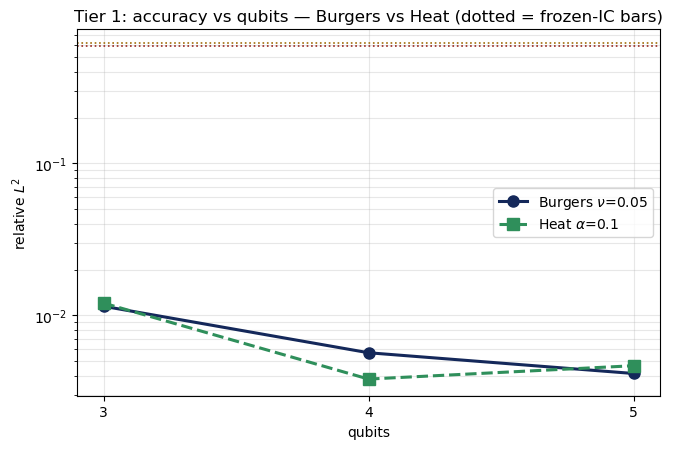

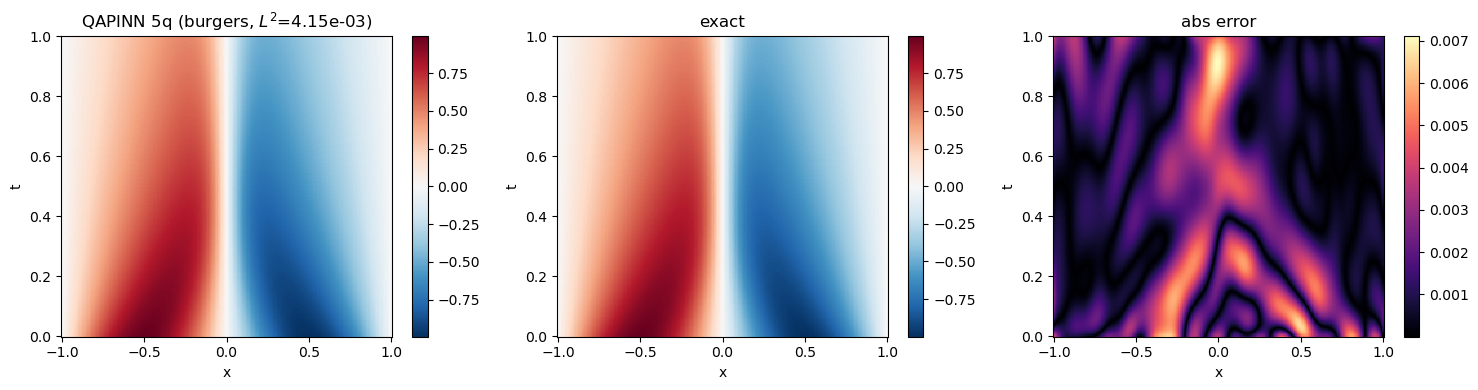

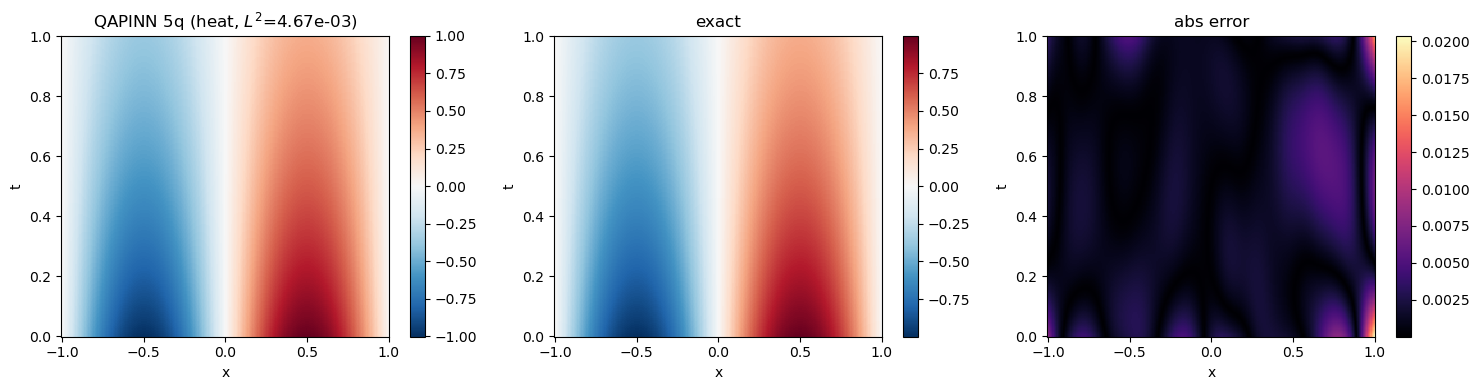

In [11]:
qs = [3, 4, 5]
plt.figure(figsize=(6.8, 4.6))
plt.semilogy(qs, [T1_results[('burgers', q)][2] for q in qs], "o-", lw=2.2, ms=8,
             color="#14285a", label=f"Burgers $\\nu$={NU_EASY}")
plt.semilogy(qs, [T1_results[('heat', q)][2] for q in qs], "s--", lw=2.2, ms=8,
             color="#2f8f5b", label=f"Heat $\\alpha$={ALPHA}")
for pde, nu, c in [("burgers", NU_EASY, "#96261e"), ("heat", ALPHA, "#a06e0a")]:
    plt.axhline(frozen_ic_baseline(pde, nu), ls=":", lw=1.2, color=c)
plt.xticks(qs); plt.xlabel("qubits"); plt.ylabel("relative $L^2$")
plt.title("Tier 1: accuracy vs qubits — Burgers vs Heat (dotted = frozen-IC bars)")
plt.grid(True, which="both", alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "T1_L2_vs_qubits.png"), dpi=150,
            bbox_inches="tight")
plt.show()

# field plots for the 5-qubit models
for pde, nu in [("burgers", NU_EASY), ("heat", ALPHA)]:
    model = T1_results[(pde, 5)][0]
    l2, up = relative_l2(model, pde, nu)
    x, t, U = reference(pde, nu)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, (Z, ttl) in zip(ax, [(up, f"QAPINN 5q ({pde}, $L^2$={l2:.2e})"),
                                (U, "exact"), (np.abs(up - U), "abs error")]):
        im = a.pcolormesh(x, t, Z, shading="auto",
                          cmap=("RdBu_r" if ttl != "abs error" else "magma"))
        a.set_title(ttl); a.set_xlabel("x"); a.set_ylabel("t")
        plt.colorbar(im, ax=a)
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_ROOT, "figures", f"T1_{pde}_q5_fields.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
# TIER 2 : (Burgers ν = 0.01/π, 5 qubits)



In [13]:
SMOKE = False    # <-- run once with True (pipeline test), then set False for the real run

if SMOKE:
    tag, nq = "T2_smoke_q3", 3
    schedule = [
        {"kind": "adam",  "lr": 8e-3, "iters": 120, "tmax": 0.4, "shock_frac": 0.3},
        {"kind": "adam",  "lr": 8e-3, "iters": 120, "tmax": 1.0, "shock_frac": 0.3},
        {"kind": "lbfgs", "iters": 100, "chunk": 50, "tmax": 1.0, "shock_frac": 0.3},
    ]
else:
    tag, nq = "T2_hero_q5", 5
    schedule = [
        {"kind": "adam",  "lr": 8e-3, "iters": 700, "tmax": 0.4, "shock_frac": 0.3},
        {"kind": "adam",  "lr": 8e-3, "iters": 600, "tmax": 0.7, "shock_frac": 0.3},
        {"kind": "adam",  "lr": 8e-3, "iters": 700, "tmax": 1.0, "shock_frac": 0.3},
        {"kind": "lbfgs", "iters": 2400, "chunk": 150, "tmax": 1.0, "shock_frac": 0.3},
    ]

print(f"=== {tag}: Burgers nu=0.01/pi, {nq} qubits, "
      f"{'SMOKE TEST' if SMOKE else 'FULL OVERNIGHT RUN'} ===")
model_t2 = QAPINN(n_qubits=nq, n_layers=6, entanglement="all",
                  measurement="expval", head_width=20, head_depth=5)
print(f"    parameters: {count_params(model_t2)}")
hist_t2 = train_schedule(tag, model_t2, "burgers", NU_HARD, schedule,
                         n_f=2500, ckpt_every=250, log_every=200)
l2_t2 = record_result(tag, model_t2, hist_t2, "burgers", NU_HARD)
print(f"\n{tag}: L2 = {l2_t2:.4e}")
if SMOKE:
    print("\nSmoke test done. If this cell ran without errors, set SMOKE=False and")
    print("re-run it tonight — the real run resumes from checkpoints if interrupted.")

=== T2_hero_q5: Burgers nu=0.01/pi, 5 qubits, FULL OVERNIGHT RUN ===
    parameters: 1853
  [T2_hero_q5] P0 adam it   200/700 loss=1.051e-01 (u=4.72e-03, f=5.80e-02) [13.3 min]
  [T2_hero_q5] P0 adam it   400/700 loss=4.656e-02 (u=1.86e-03, f=2.80e-02) [24.9 min]
  [T2_hero_q5] P0 adam it   600/700 loss=1.258e-02 (u=4.44e-04, f=8.14e-03) [39.7 min]
  [T2_hero_q5] P1 adam it   200/600 loss=3.419e-02 (u=9.54e-04, f=2.47e-02) [57.2 min]
  [T2_hero_q5] P1 adam it   400/600 loss=1.428e-02 (u=3.14e-04, f=1.11e-02) [68.8 min]
  [T2_hero_q5] P1 adam it   600/600 loss=9.966e-03 (u=1.80e-04, f=8.16e-03) [80.4 min]
  [T2_hero_q5] P2 adam it   200/700 loss=2.451e-02 (u=5.41e-04, f=1.91e-02) [92.1 min]
  [T2_hero_q5] P2 adam it   400/700 loss=8.966e-03 (u=1.36e-04, f=7.61e-03) [103.9 min]
  [T2_hero_q5] P2 adam it   600/700 loss=6.723e-03 (u=1.08e-04, f=5.64e-03) [115.5 min]
  [T2_hero_q5] P3 lbfgs chunk 1/16 loss=3.841e-03 (u=6.80e-05, f=3.16e-03) [131.7 min]
  [T2_hero_q5] P3 lbfgs chunk 2/16 los

## Tier 2 : evaluation


Tier-2 hero L2 = 3.5674e-03
  vs crude no-learning guess : 0.491
  vs best previous (v3, q3)  : 0.330
  vs Phase-1 classical (50k) : 2.12e-4
  => STRONG result: usable as the hard-benchmark headline.


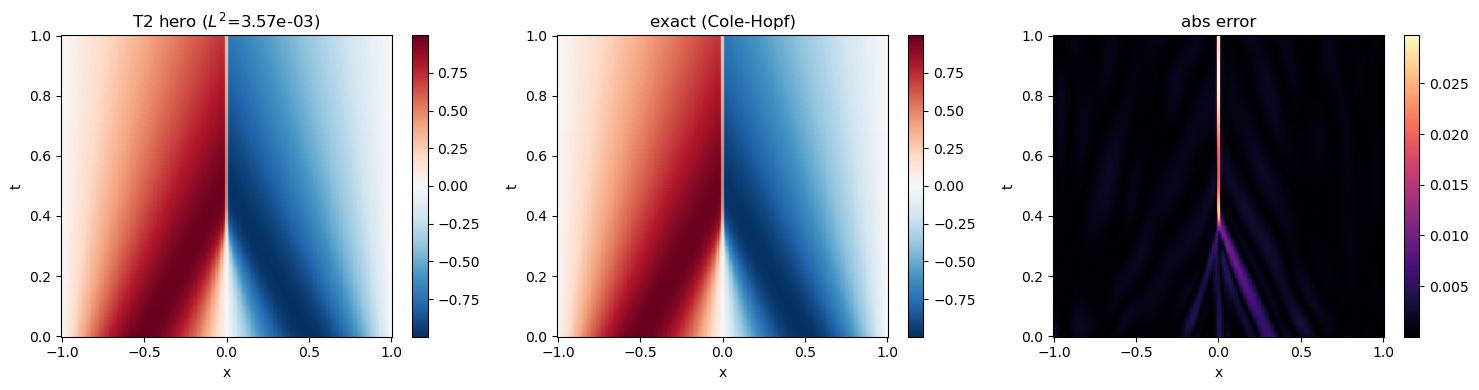

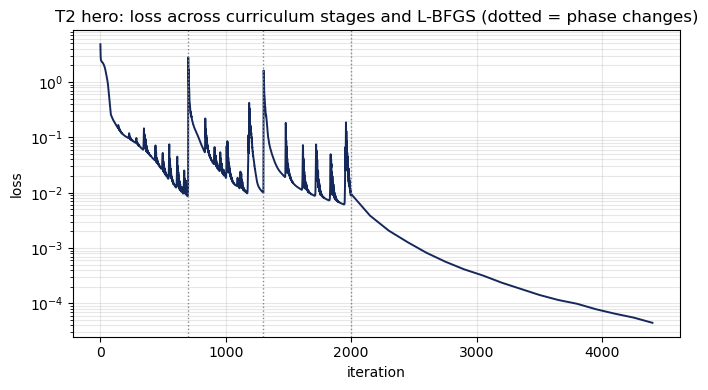

In [14]:
if not SMOKE:
    print(f"Tier-2 hero L2 = {l2_t2:.4e}")
    print(f"  vs crude no-learning guess : 0.491")
    print(f"  vs best previous (v3, q3)  : 0.330")
    print(f"  vs Phase-1 classical (50k) : 2.12e-4")
    if l2_t2 < 0.15:
        print("  => STRONG result: usable as the hard-benchmark headline.")
    elif l2_t2 < 0.30:
        print("  => Improvement over every previous attempt; usable with honest framing.")
    else:
        print("  => Did not beat v3: report as the documented hard-viscosity finding")
        print("     (ties directly into the Phase-3 Fourier/expressivity analysis).")

    l2s, up = relative_l2(model_t2, "burgers", NU_HARD)
    x, t, U = reference("burgers", NU_HARD)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, (Z, ttl) in zip(ax, [(up, f"T2 hero ($L^2$={l2s:.2e})"),
                                (U, "exact (Cole-Hopf)"), (np.abs(up - U), "abs error")]):
        im = a.pcolormesh(x, t, Z, shading="auto",
                          cmap=("RdBu_r" if ttl != "abs error" else "magma"))
        a.set_title(ttl); a.set_xlabel("x"); a.set_ylabel("t")
        plt.colorbar(im, ax=a)
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_ROOT, "figures", "T2_hero_fields.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    d = np.load(os.path.join(CKPT_ROOT, "results", "T2_hero_q5_history.npz"))
    plt.figure(figsize=(7, 4))
    plt.semilogy(d["iters"], d["loss"], lw=1.4, color="#14285a")
    for pb in np.where(np.diff(d["phase"]) > 0)[0]:
        plt.axvline(d["iters"][pb], ls=":", color="#888", lw=1)
    plt.xlabel("iteration"); plt.ylabel("loss")
    plt.title("T2 hero: loss across curriculum stages and L-BFGS (dotted = phase changes)")
    plt.grid(True, which="both", alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(CKPT_ROOT, "figures", "T2_hero_loss.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("(smoke mode — set SMOKE=False and run the hero cell for the real evaluation)")